<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [ ]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

#### 2. Connect to the Database


**Install the needed libraries**


In [ ]:
!pip install pandas

In [ ]:
!pip install matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sqlite3
import os

# 1. Ścieżka do Twojego pliku CSV
csv_path = '/Users/michalbando/Downloads/Różne/IT/Python/data/survey_data_newest.csv'
db_name = 'local_survey.db'

# 2. Usuwamy starą bazę, jeśli istnieje, żeby zacząć "na czysto"
if os.path.exists(db_name):
    os.remove(db_name)

# 3. Wczytujemy plik CSV do Pandas
df = pd.read_csv(csv_path)

# 4. Tworzymy połączenie sqlite3 i zapisujemy DataFrame jako tabelę 'main'
# To stworzy PRAWIDŁOWY plik bazy danych .db
conn = sqlite3.connect(db_name)
df.to_sql('main', conn, index=False, if_exists='replace')

# 5. Konfiguracja magii SQL
%load_ext sql
%config SqlMagic.style = '_DEPRECATED_DEFAULT' # Naprawa błędu KeyError: 'DEFAULT'
%sql sqlite:///local_survey.db

print(f"Sukces! Wczytano {len(df)} wierszy do tabeli 'main' w bazie {db_name}.")

Sukces! Wczytano 65437 wierszy do tabeli 'main' w bazie local_survey.db.


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [2]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [ ]:
QUERY = """
SELECT name as Table_Name
FROM sqlite_master
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [ ]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


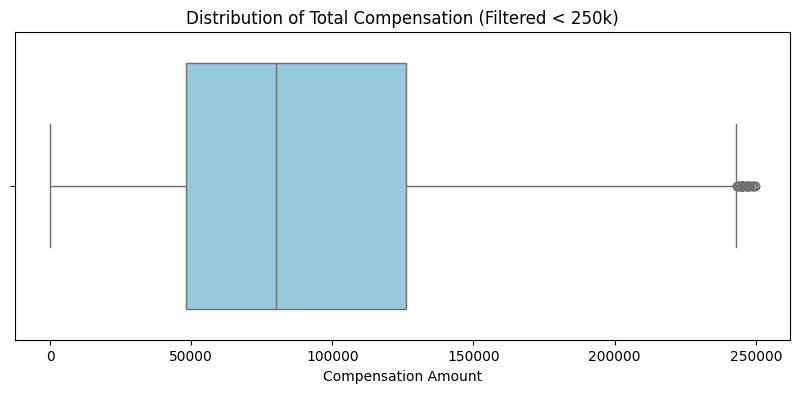

In [22]:
query = "SELECT CompTotal FROM main WHERE CompTotal IS NOT NULL AND CompTotal < 250000"
df_comp = pd.read_sql_query(query, conn)

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_comp['CompTotal'], color='skyblue')
plt.title('Distribution of Total Compensation (Filtered < 250k)')
plt.xlabel('Compensation Amount')
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


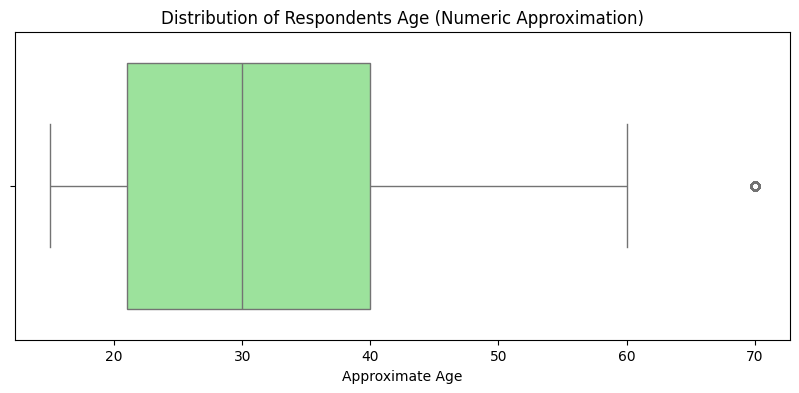

In [23]:
query = "SELECT Age FROM main WHERE Age IS NOT NULL"
df_age = pd.read_sql_query(query, conn)

# Mapowanie na liczby (środki przedziałów lub indeksy)
age_map = {
    'Under 18 years old': 15, '18-24 years old': 21, '25-34 years old': 30,
    '35-44 years old': 40, '45-54 years old': 50, '55-64 years old': 60,
    '65 years or older': 70
}
df_age['AgeNumeric'] = df_age['Age'].map(age_map)

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_age['AgeNumeric'], color='lightgreen')
plt.title('Distribution of Respondents Age (Numeric Approximation)')
plt.xlabel('Approximate Age')
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


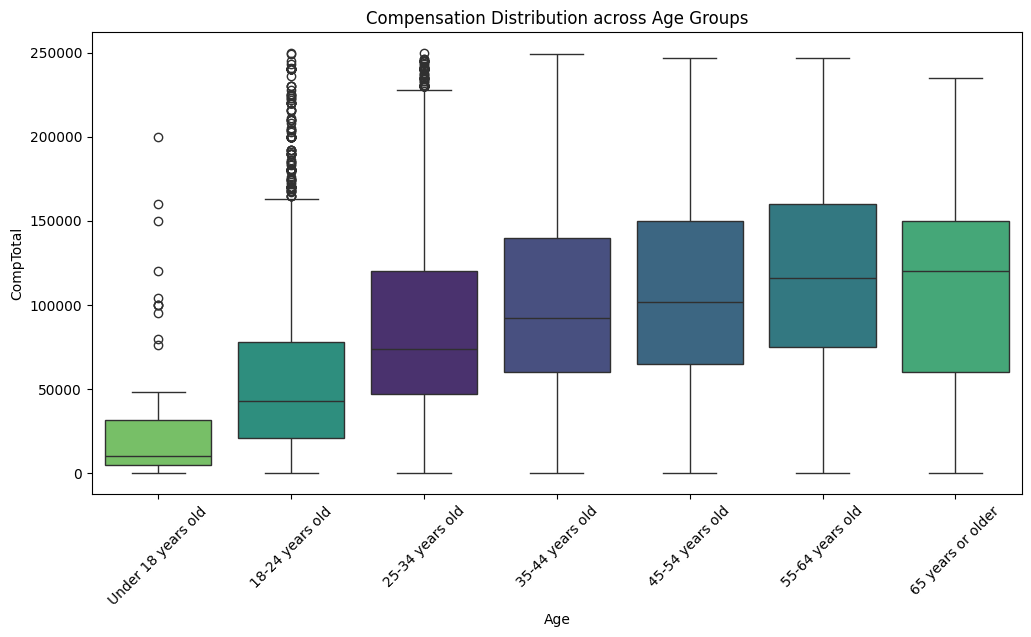

In [ ]:
query = "SELECT CompTotal, Age FROM main WHERE CompTotal IS NOT NULL AND CompTotal < 250000"
df_age_comp = pd.read_sql_query(query, conn)

age_order = ['Under 18 years old', '18-24 years old', '25-34 years old',
             '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_age_comp, x='Age', y='CompTotal', order=age_order, palette='viridis', hue='Age', legend=False)
plt.title('Compensation Distribution across Age Groups')
plt.xticks(rotation=45)
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


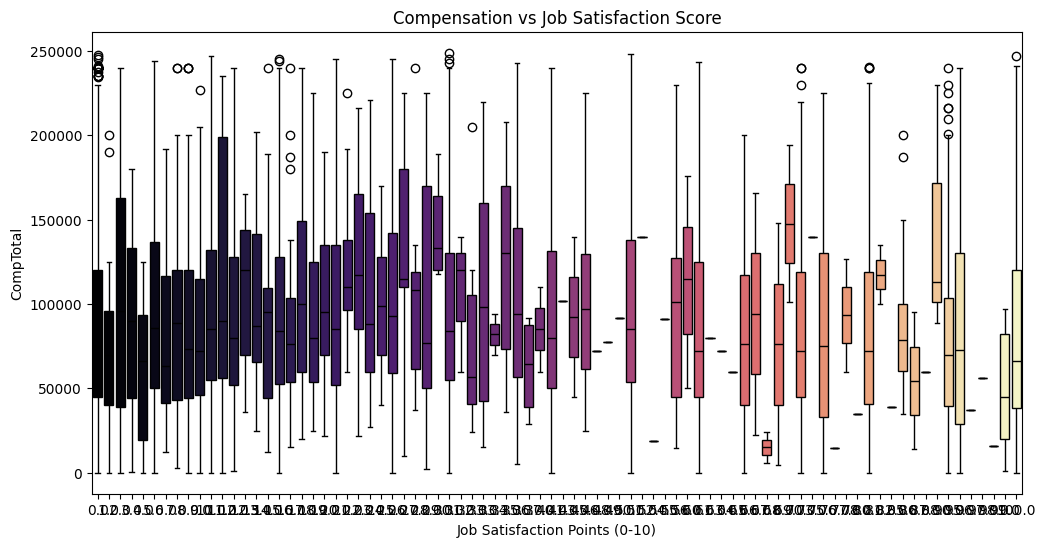

In [25]:

query = "SELECT CompTotal, JobSatPoints_6 FROM main WHERE CompTotal IS NOT NULL AND CompTotal < 250000"
df_sat_comp = pd.read_sql_query(query, conn)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_sat_comp, x='JobSatPoints_6', y='CompTotal', palette='magma', hue='JobSatPoints_6', legend=False)
plt.title('Compensation vs Job Satisfaction Score')
plt.xlabel('Job Satisfaction Points (0-10)')
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


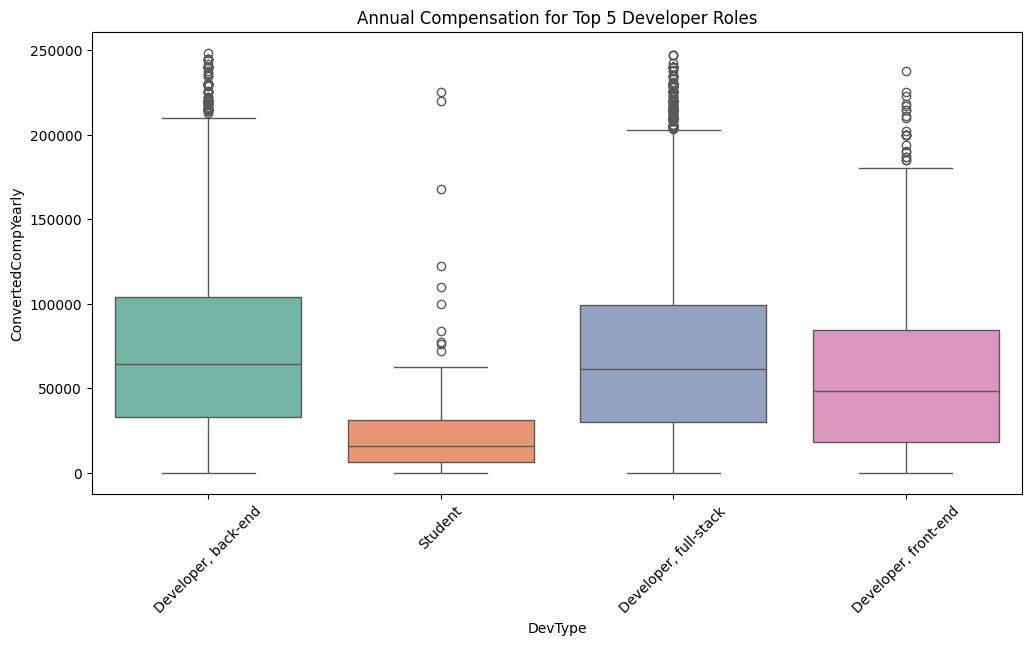

In [35]:
# 1. Najpierw pobieramy listę Top 5 ról za pomocą SQL
query_top5 = "SELECT DevType, COUNT(*) as count FROM main GROUP BY DevType ORDER BY count DESC LIMIT 5"
top_5_roles = pd.read_sql_query(query_top5, conn)['DevType'].tolist()

# 2. Pobieramy dane dla tych ról (używając parametrów dla bezpieczeństwa)
query = f"SELECT ConvertedCompYearly, DevType FROM main WHERE DevType IN ({','.join(['?']*len(top_5_roles))}) AND ConvertedCompYearly < 250000"
df_top5 = pd.read_sql_query(query, conn, params=top_5_roles)

# 3. Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top5, x='DevType', y='ConvertedCompYearly', palette='Set2', hue='DevType', legend=False)
plt.title('Annual Compensation for Top 5 Developer Roles')
plt.xticks(rotation=45)
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


/var/folders/77/bxgbvz0s0r14k6cfkqvfpr9m0000gn/T/ipykernel_10587/1322025103.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_code_sat, x='JobSatPoints_6', y='YearsCodePro', palette='terrain')


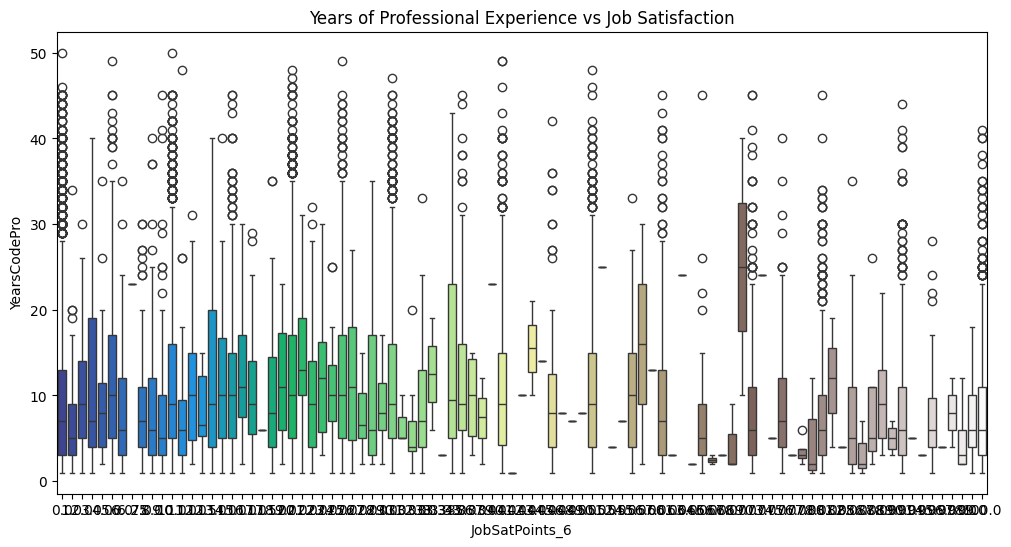

In [31]:
# Task 4.2
query = "SELECT YearsCodePro, JobSatPoints_6 FROM main WHERE YearsCodePro IS NOT NULL"
df_code_sat = pd.read_sql_query(query, conn)

df_code_sat['YearsCodePro'] = pd.to_numeric(df_code_sat['YearsCodePro'], errors='coerce')
df_code_sat.dropna(subset=['YearsCodePro'], inplace=True)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_code_sat, x='JobSatPoints_6', y='YearsCodePro', palette='terrain')
plt.title('Years of Professional Experience vs Job Satisfaction')
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


/var/folders/77/bxgbvz0s0r14k6cfkqvfpr9m0000gn/T/ipykernel_10587/1137080504.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_41, x='Age', y='CompTotal', palette='pastel')


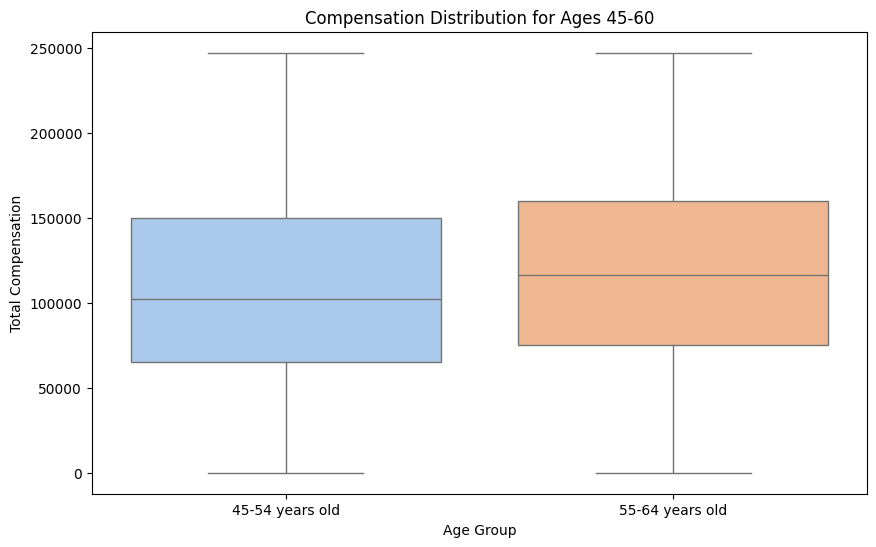

In [ ]:
# 1. SQL Query z filtrem wieku i usunięciem outlierów
query_41 = """
SELECT CompTotal, Age
FROM main
WHERE (Age = '45-54 years old' OR Age = '55-64 years old')
  AND CompTotal IS NOT NULL
  AND CompTotal < 250000
"""
df_41 = pd.read_sql_query(query_41, conn)

# 2. Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_41, x='Age', y='CompTotal', palette='pastel')
plt.title('Compensation Distribution for Ages 45-60')
plt.xlabel('Age Group')
plt.ylabel('Total Compensation')
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


/var/folders/77/bxgbvz0s0r14k6cfkqvfpr9m0000gn/T/ipykernel_10587/3518617908.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_42, x='JobSatPoints_6', y='YearsCodePro', palette='coolwarm')


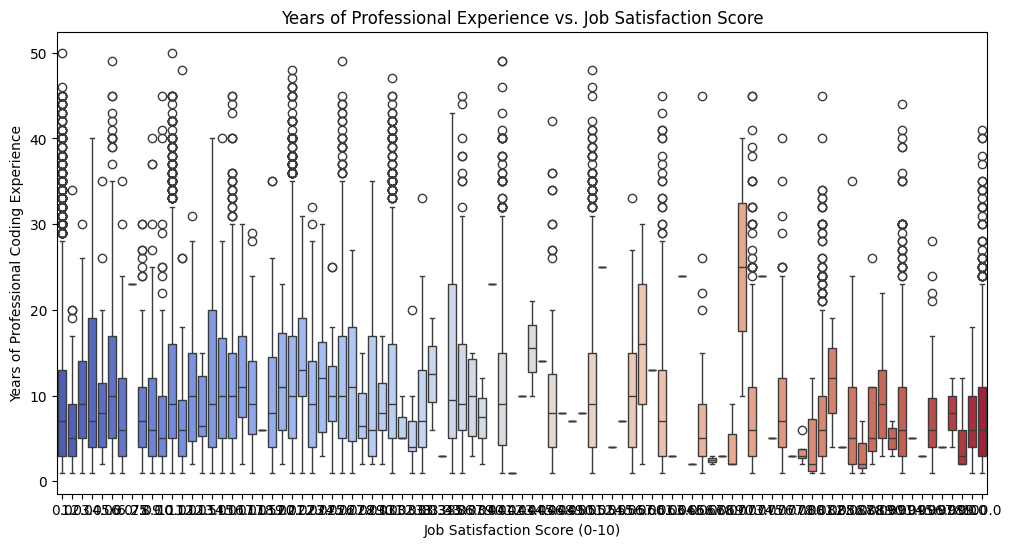

In [37]:
# 1. SQL Query
query_42 = "SELECT YearsCodePro, JobSatPoints_6 FROM main WHERE YearsCodePro IS NOT NULL AND JobSatPoints_6 IS NOT NULL"
df_42 = pd.read_sql_query(query_42, conn)

# 2. Czyszczenie danych (YearsCodePro na typ numeryczny)
df_42['YearsCodePro'] = pd.to_numeric(df_42['YearsCodePro'], errors='coerce')
df_42.dropna(inplace=True)

# 3. Box Plot
plt.figure(figsize=(12, 6))
# Pokazujemy rozkład lat doświadczenia dla każdego poziomu satysfakcji (0-10)
sns.boxplot(data=df_42, x='JobSatPoints_6', y='YearsCodePro', palette='coolwarm')
plt.title('Years of Professional Experience vs. Job Satisfaction Score')
plt.xlabel('Job Satisfaction Score (0-10)')
plt.ylabel('Years of Professional Coding Experience')
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [ ]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
